**"Salifort Motors was losing roughly 1 in 6 employees and didn't know why. I analyzed their HR data, built a machine learning model that predicts with 98% accuracy which employees are likely to leave and why — giving HR a concrete, actionable tool to intervene before it's too late."**

# Employee Attrition Prediction at Salifort Motors
## A Data-Driven Approach to HR Analytics and Employee Retention

---

### Project Overview

Salifort Motors is a multinational vehicle manufacturing corporation facing
a significant challenge: a high rate of employee turnover. Losing employees
is not only disruptive to operations — it is also costly. Recruiting,
interviewing, onboarding, and training new employees requires substantial
time and financial investment.

The HR department collected self-reported survey data from employees across
the company and commissioned a data analytics project to answer one central
question:

> **What is likely to make an employee leave Salifort Motors — and can we
> predict it before it happens?**

---

### Objectives

This project pursues two goals:

1. **Understand** the key factors that drive employee turnover through exploratory data analysis
2. **Predict** whether an individual employee is likely to leave the company using machine learning models

---

### Approach

- **Exploratory Data Analysis (EDA)** to identify patterns, relationships, and risk factors
- **Machine Learning Modeling** using Logistic Regression, Decision Tree, Random Forest, and XGBoost
- **Model Evaluation** using Precision, Recall, F1-Score, and ROC-AUC
- **Practical Application** to generate an actionable at-risk employee report

---
## Dataset

The dataset contains **15,000 rows** and **10 columns** of self-reported employee information.

| Variable | Type | Description |
|----------|------|-------------|
| `satisfaction_level` | float | Employee-reported job satisfaction level [0–1] |
| `last_evaluation` | float | Score of employee's last performance review [0–1] |
| `number_project` | int | Number of projects employee contributes to |
| `average_monthly_hours` | int | Average number of hours employee worked per month |
| `time_spend_company` | int | How long the employee has been with the company (years) |
| `Work_accident` | int | Whether the employee experienced an accident while at work |
| `left` | int | Whether the employee left the company |
| `promotion_last_5years` | int | Whether the employee was promoted in the last 5 years |
| `Department` | str | The employee's department |
| `salary` | str | The employee's salary level (low / medium / high) |

---
## Step 1. Imports

### Import packages

In [34]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('All libraries loaded successfully ✓')

# Create folder for saving plots
import os
os.makedirs('plots', exist_ok=True)
print('Plots folder ready ✓')

All libraries loaded successfully ✓
Plots folder ready ✓


### Load dataset

In [35]:
# Load dataset into a dataframe
df0 = pd.read_csv('HR_capstone_dataset.csv')

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


---
## Step 2. Data Exploration & Cleaning

### Gather basic information about the data

In [36]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [37]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns
Standardizing column names to `snake_case` and fixing typos.

In [38]:
# Display all column names
print(df0.columns.tolist())

['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


In [39]:
# Rename columns as needed
df0 = df0.rename(columns={
    'average_montly_hours': 'average_monthly_hours',  # fix typo
    'time_spend_company':   'tenure',
    'Work_accident':        'work_accident',
    'Department':           'department',
})

# Display all column names after the update
print(df0.columns.tolist())

['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'left', 'promotion_last_5years', 'department', 'salary']


### Check missing values

In [40]:
# Check for missing values
print('Missing values per column:')
print(df0.isnull().sum())
print(f'\nTotal missing: {df0.isnull().sum().sum()}')

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

Total missing: 0


### Check duplicates

In [41]:
# Check for duplicates
print(f'Number of duplicate rows: {df0.duplicated().sum()}')

Number of duplicate rows: 3008


In [42]:
# Inspect duplicates – show original AND duplicate rows together, sorted for comparison
df0[df0.duplicated(keep=False)].sort_values(by=df0.columns.tolist()).head(20)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
30,0.09,0.62,6,294,4,0,1,0,accounting,low
12030,0.09,0.62,6,294,4,0,1,0,accounting,low
14241,0.09,0.62,6,294,4,0,1,0,accounting,low
71,0.09,0.77,5,275,4,0,1,0,product_mng,medium
12071,0.09,0.77,5,275,4,0,1,0,product_mng,medium
14282,0.09,0.77,5,275,4,0,1,0,product_mng,medium
652,0.09,0.77,6,290,4,0,1,0,technical,medium
12652,0.09,0.77,6,290,4,0,1,0,technical,medium
14863,0.09,0.77,6,290,4,0,1,0,technical,medium
278,0.09,0.78,6,254,4,0,1,0,support,low


In [43]:
# Drop duplicates and save resulting dataframe in a new variable
df1 = df0.drop_duplicates(keep='first')

# Display shape after cleaning
print(f'Shape after dropping duplicates: {df1.shape}')
df1.head()

Shape after dropping duplicates: (11991, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

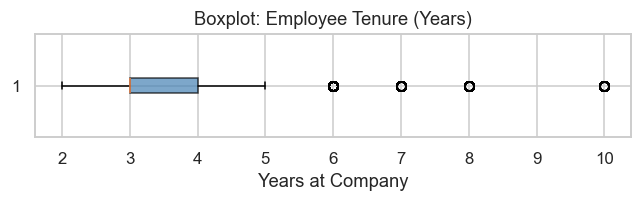

In [44]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
fig, ax = plt.subplots(figsize=(6, 2))
ax.boxplot(df1['tenure'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_title('Boxplot: Employee Tenure (Years)')
ax.set_xlabel('Years at Company')
plt.tight_layout()
plt.show()

In [45]:
# Determine the number of rows containing outliers (IQR method on 'tenure')
q1 = df1['tenure'].quantile(0.25)
q3 = df1['tenure'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df1[(df1['tenure'] < lower) | (df1['tenure'] > upper)]

print(f'Q1={q1}, Q3={q3}, IQR={iqr}')
print(f'Lower bound={lower}, Upper bound={upper}')
print(f'Number of outlier rows: {len(outliers)} ({len(outliers)/len(df1)*100:.1f}% of total)')

# Count and percentage per tenure value
outlier_summary = outliers['tenure'].value_counts().sort_index().to_frame(name='count')
outlier_summary['% of total'] = (outlier_summary['count'] / len(df1) * 100).round(2)
outlier_summary

Q1=3.0, Q3=4.0, IQR=1.0
Lower bound=1.5, Upper bound=5.5
Number of outlier rows: 824 (6.9% of total)


,count,% of total
tenure,,
6,542,4.52
7,94,0.78
8,81,0.68
10,107,0.89


---
## Step 3. Exploratory Data Analysis (EDA)

### How many employees left?

In [46]:
# Get numbers and percentages of people who left vs. stayed
left_counts = df1['left'].value_counts()
left_pct = df1['left'].value_counts(normalize=True) * 100
print('Counts:')
print(left_counts)
print('\nPercentages:')
print(left_pct.round(1))

Counts:
left
0    10000
1     1991
Name: count, dtype: int64

Percentages:
left
0    83.4
1    16.6
Name: proportion, dtype: float64


### Data visualizations

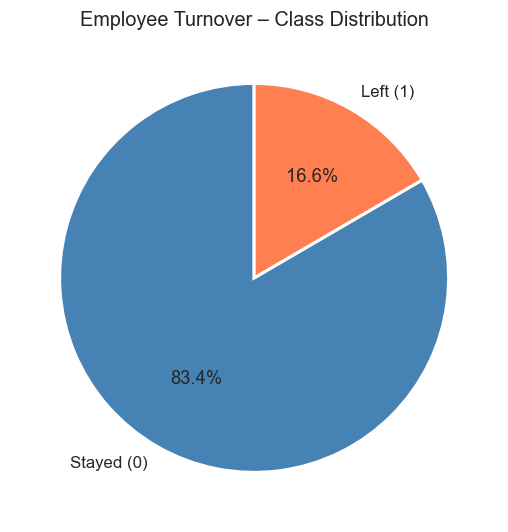

In [47]:
# Plot 1: Class distribution of target variable
left_counts = df1['left'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    left_counts,
    labels=['Stayed (0)', 'Left (1)'],
    colors=['steelblue', 'coral'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Employee Turnover – Class Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: Class Imbalance in Employee Turnover

| Status | Share |
|--------|-------|
| Stayed | 83.4% |
| Left | 16.6% |

Despite appearing as a minority, the 16.6% turnover rate represents a substantial
and costly challenge for Salifort Motors. The class imbalance also means that
accuracy alone is a misleading metric — **Precision, Recall and F1-score** are
more meaningful evaluation criteria. Models are trained with `class_weight='balanced'`
to avoid bias towards the majority class.

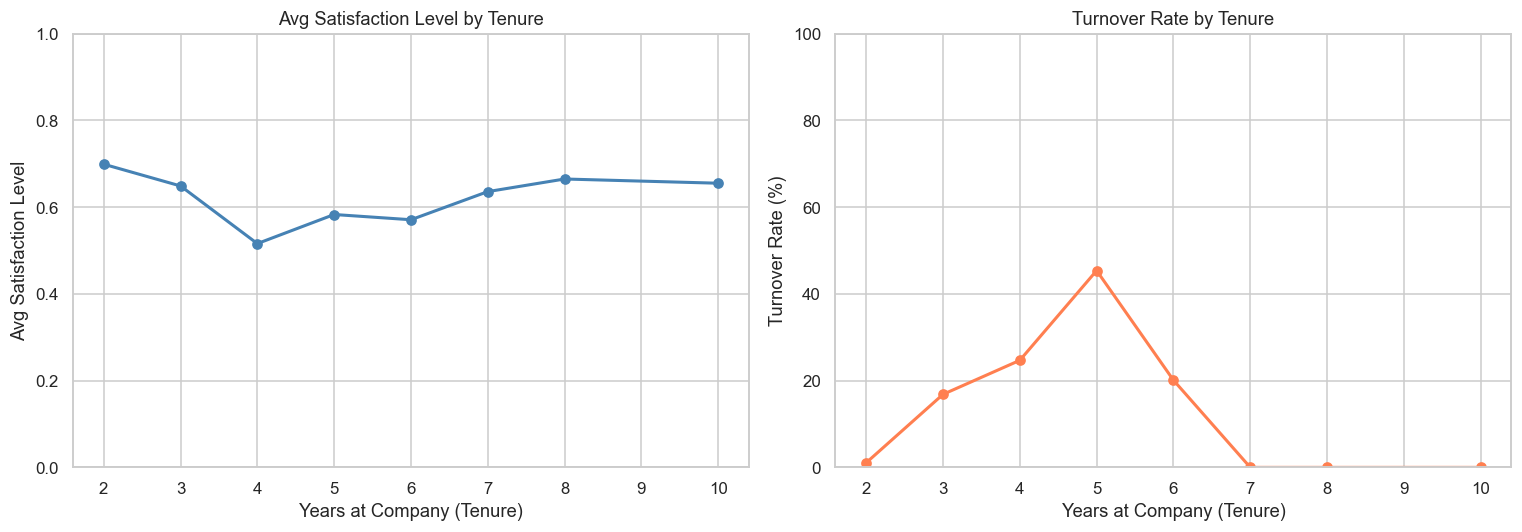

In [48]:
# Plot 2: Satisfaction by Tenure and Turnover Rate by Tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df1.groupby('tenure')['satisfaction_level'].mean().plot(
    ax=axes[0], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Avg Satisfaction Level by Tenure')
axes[0].set_xlabel('Years at Company (Tenure)')
axes[0].set_ylabel('Avg Satisfaction Level')
axes[0].set_ylim(0, 1)

df1.groupby('tenure')['left'].mean().mul(100).plot(
    ax=axes[1], marker='o', color='coral', linewidth=2)
axes[1].set_title('Turnover Rate by Tenure')
axes[1].set_xlabel('Years at Company (Tenure)')
axes[1].set_ylabel('Turnover Rate (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('plots/02_satisfaction_turnover_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: Satisfaction Decline Predicts Turnover Peak

Satisfaction reaches its lowest point at **year 4** (~0.52), followed by a
turnover spike of nearly **45% at year 5**. Employees in years 3–4 represent
the highest-risk group for proactive retention efforts.

| Year | Avg Satisfaction | Turnover Rate |
|------|-----------------|---------------|
| 2 | ~0.70 | ~2% |
| 3 | ~0.65 | ~17% |
| 4 | ~0.52 ← lowest | ~25% |
| 5 | ~0.58 | ~45% ← peak |

> Proactive retention measures — salary reviews, career conversations, promotions —
> should be targeted at employees in their **3rd and 4th year** before dissatisfaction
> turns into departure.

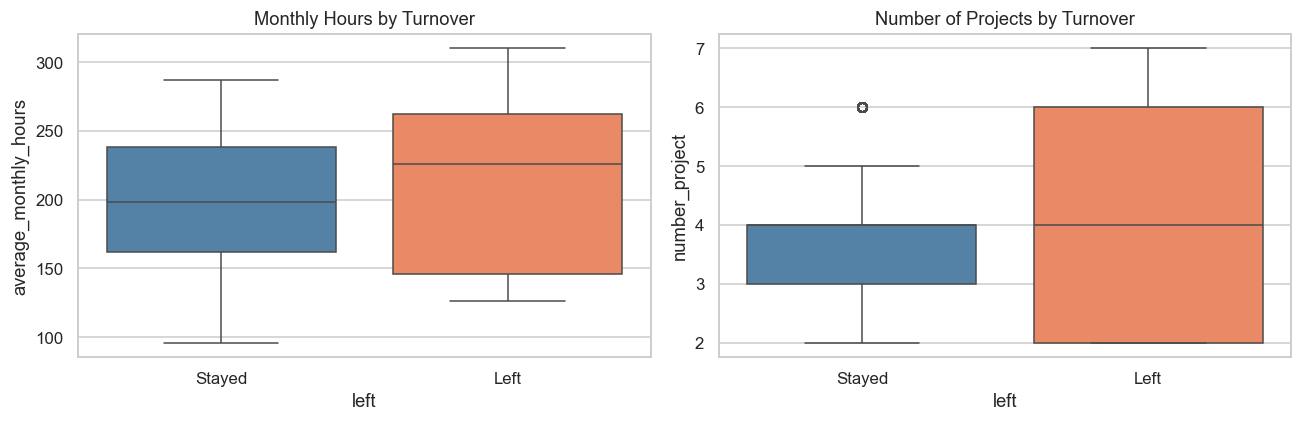

In [49]:
# Plot 3: Monthly hours and project count by turnover
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df1, x='left', y='average_monthly_hours', ax=axes[0],
            hue='left', palette=['steelblue', 'coral'], legend=False)
axes[0].set_title('Monthly Hours by Turnover')
axes[0].set_xticklabels(['Stayed', 'Left'])

sns.boxplot(data=df1, x='left', y='number_project', ax=axes[1],
            hue='left', palette=['steelblue', 'coral'], legend=False)
axes[1].set_title('Number of Projects by Turnover')
axes[1].set_xticklabels(['Stayed', 'Left'])

plt.tight_layout()
plt.savefig('plots/03_workload_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: Working Hours and Project Load Drive Turnover

Employees who left show a much **wider spread** in both monthly hours and project
count compared to those who stayed. This confirms two distinct risk groups:

- **Overloaded**: median ~230 hrs/month, up to 6–7 projects → burnout risk
- **Underutilized**: below average hours, as few as 2 projects → disengagement risk

> Turnover is not driven by a single workload pattern. Both extremes are equally dangerous.

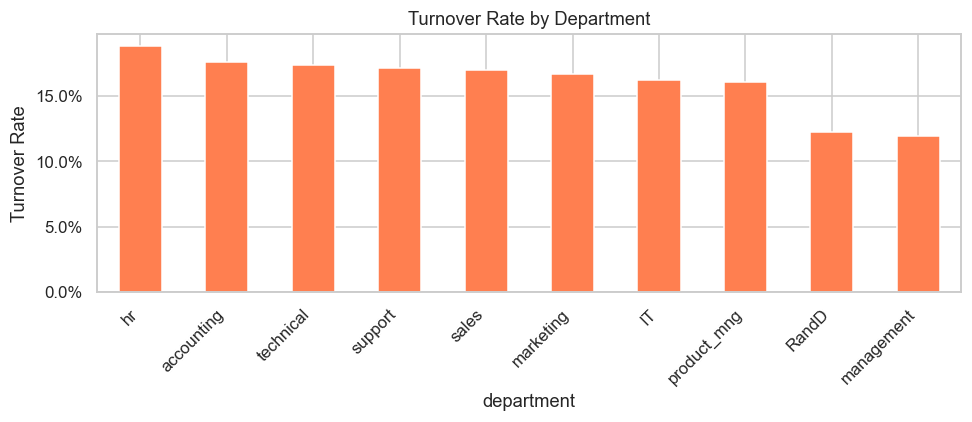

In [50]:
# Plot 4: Turnover rate by department
dept_turnover = df1.groupby('department')['left'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
dept_turnover.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Turnover Rate by Department')
ax.set_ylabel('Turnover Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/04_turnover_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: Turnover is a Company-Wide Problem

All departments fall within a narrow range of **12%–19%** — turnover is systemic,
not isolated to any single team. No department-specific intervention will be sufficient.

| Department | Turnover Rate |
|------------|---------------|
| HR | ~19% ← highest |
| Accounting / Technical | ~17% |
| Management | ~12% ← lowest |

> Retention strategies must be implemented **across the entire organization**.

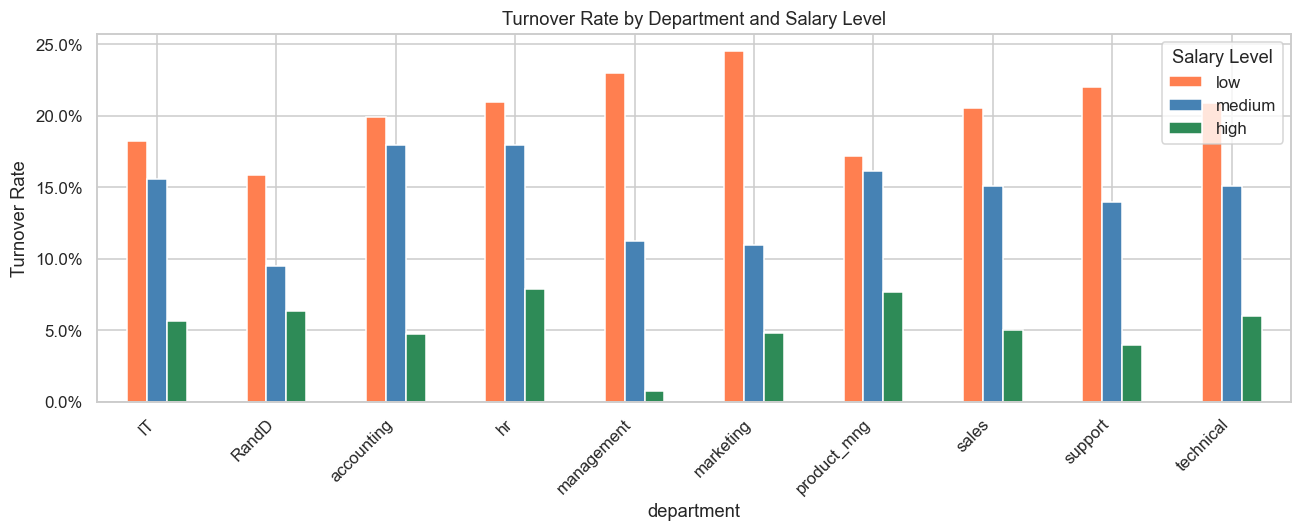

In [51]:
# Plot 5: Turnover rate by department AND salary level
pivot = df1.groupby(['department', 'salary'])['left'].mean().unstack()
pivot = pivot[['low', 'medium', 'high']]

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, color=['coral', 'steelblue', 'seagreen'], edgecolor='white')
ax.set_title('Turnover Rate by Department and Salary Level')
ax.set_ylabel('Turnover Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Salary Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/05_turnover_department_salary.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: Salary is the Strongest Driver of Turnover Across All Departments

Across **every single department**, the same pattern holds:

| Salary Level | Turnover Rate |
|--------------|---------------|
| Low | 17% – 25% |
| Medium | 9% – 18% |
| High | 1% – 8% |

> Salary level is a **stronger predictor of turnover than department**. Targeted
> salary adjustments for low and medium earners would have the greatest company-wide impact.

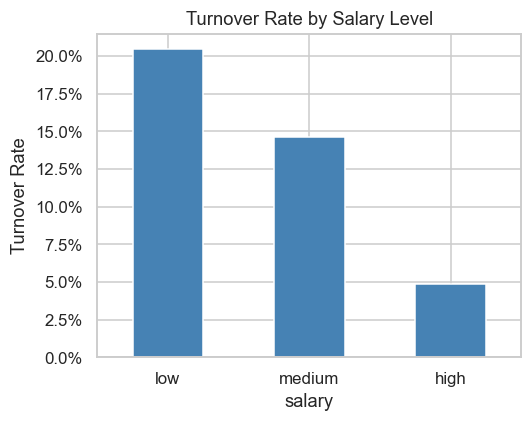

In [52]:
# Plot 6: Turnover rate by salary level
salary_order = ['low', 'medium', 'high']
salary_turnover = df1.groupby('salary')['left'].mean().reindex(salary_order)
fig, ax = plt.subplots(figsize=(5, 4))
salary_turnover.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Turnover Rate by Salary Level')
ax.set_ylabel('Turnover Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/06_turnover_by_salary.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: Lower Salary, Higher Turnover

| Salary Level | Turnover Rate |
|--------------|---------------|
| Low | ~20% |
| Medium | ~15% |
| High | ~5% |

Low-salary employees are **4x more likely** to leave than high earners. Salary
adjustments can be implemented directly and are likely to produce **immediate
reductions in turnover**.

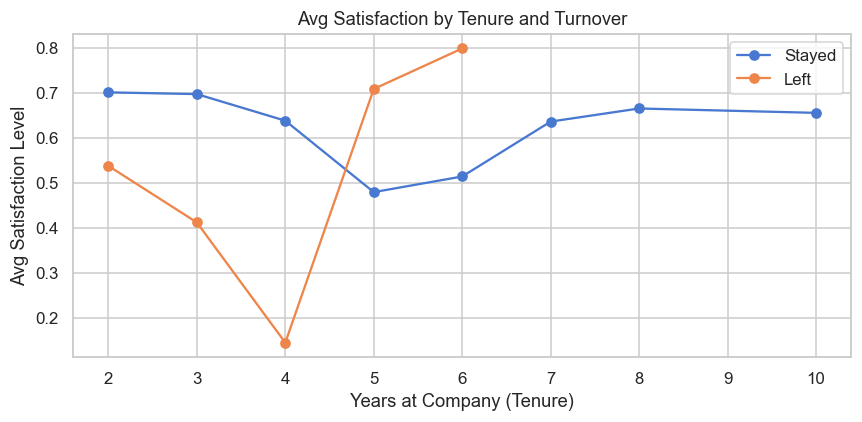

In [53]:
# Plot 7: Average satisfaction by tenure and turnover status
tenure_sat = df1.groupby(['tenure', 'left'])['satisfaction_level'].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 4))
tenure_sat.plot(ax=ax, marker='o')
ax.set_title('Avg Satisfaction by Tenure and Turnover')
ax.set_xlabel('Years at Company (Tenure)')
ax.set_ylabel('Avg Satisfaction Level')
ax.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('plots/07_satisfaction_by_tenure_turnover.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: When Employees Leave Reveals Why They Leave

The satisfaction level **at the moment of departure** reveals two fundamentally
different types of leavers:

| Tenure | Satisfaction at Departure | Type | Root Cause |
|--------|--------------------------|------|------------|
| Year 3–4 | ~0.16 – 0.41 | Pushed out | Burnout, frustration |
| Year 5–6 | ~0.71 – 0.80 | Pulled away | Better opportunities elsewhere |

> Salifort Motors is losing employees for **two fundamentally different reasons**.
> Early leavers need to be **supported and relieved**. Experienced leavers need
> to be **rewarded and challenged**.

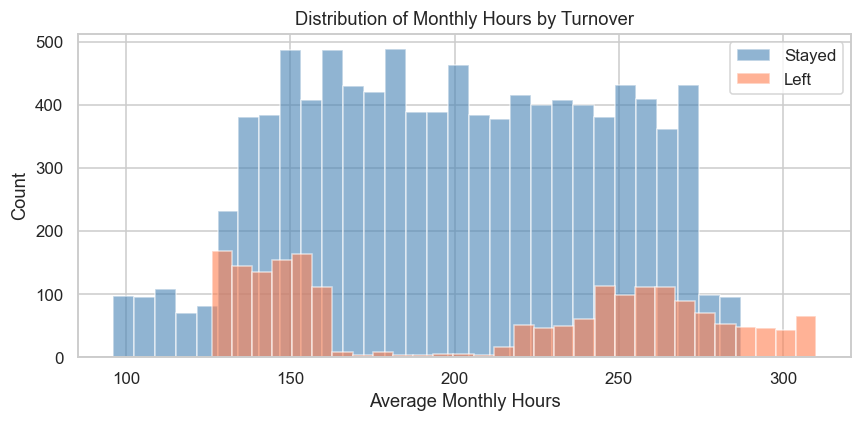

In [54]:
# Plot 8: Distribution of average monthly hours by turnover
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, 'steelblue', 'Stayed'), (1, 'coral', 'Left')]:
    df1[df1['left'] == label]['average_monthly_hours'].hist(
        ax=ax, bins=30, alpha=0.6, color=color, label=name)
ax.set_title('Distribution of Monthly Hours by Turnover')
ax.set_xlabel('Average Monthly Hours')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('plots/08_monthly_hours_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight: A "Safe Zone" of Working Hours Exists

Employees who left cluster into two distinct groups at opposite ends of the
working hours spectrum:

| Zone | Monthly Hours | Risk Level |
|------|--------------|------------|
| Underload | < 150 hrs | 🔴 High |
| Safe Zone | 160 – 240 hrs | 🟢 Low |
| Overload | > 240 hrs | 🔴 High |

> Monthly working hours are a **directly measurable early warning signal**.
> HR should flag any employee consistently working below 150 or above 240
> hours per month for immediate follow-up.

---
## Executive Summary: Key Findings from EDA

### The Core Problem
Salifort Motors is experiencing a **16.6% turnover rate** — roughly 1 in 6
employees leaves the company. This is a systemic, company-wide issue.

### Five Key Drivers of Turnover

**1. Satisfaction is the Strongest Predictor**
Low satisfaction is the single most measurable signal of future departure.
Employees who leave in their early years do so with extremely low satisfaction
(as low as 0.16).

**2. Salary has a Direct and Dramatic Impact**
Low-salary employees leave at **4x the rate** of high earners (20% vs. 5%),
consistently across every department.

**3. Workload Extremes Drive Departure**
There is a clear "safe zone" of 160–240 monthly working hours. Employees
outside this range show significantly higher turnover risk.

**4. Year 4–5 is the Critical Turning Point**
Satisfaction reaches its lowest point at year 4, followed by a turnover
peak of ~45% at year 5.

**5. Two Types of Leavers Require Two Strategies**

| Type | Tenure | Satisfaction | Action Needed |
|------|--------|--------------|---------------|
| Pushed out | 3–4 years | Very low | Reduce workload, increase support |
| Pulled away | 5–6 years | Very high | Promote, reward, create career paths |

---
## Step 4. Model Building

Four models are built and compared:
1. **Logistic Regression** — baseline, linear model
2. **Decision Tree** — interpretable, non-linear
3. **Random Forest** — ensemble, robust against overfitting
4. **XGBoost** — gradient boosting, typically highest performance

### Data Preparation

In [55]:
### DATA PREPARATION ###

# Work on a clean copy to avoid modifying the original dataframe
df_model = df1.copy()

# Ordinal-encode salary: preserves natural order (low < medium < high)
salary_map = {'low': 0, 'medium': 1, 'high': 2}
df_model['salary'] = df_model['salary'].map(salary_map)

# One-hot encode department: converts categorical text values into binary columns
# drop_first=True removes one column to avoid multicollinearity (dummy variable trap)
df_model = pd.get_dummies(df_model, columns=['department'], drop_first=True)

# Separate features (X) from target variable (y)
X = df_model.drop('left', axis=1)
y = df_model['left']

# Split data into three sets:
# - Train (60%):      used to fit the model
# - Validation (20%): used to tune hyperparameters and compare models
# - Test (20%):       used only once at the end for final evaluation
# stratify=y ensures each split has the same class ratio as the original dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train:      {X_train.shape[0]:,} rows')
print(f'Validation: {X_val.shape[0]:,} rows')
print(f'Test:       {X_test.shape[0]:,} rows')

Train:      7,194 rows
Validation: 2,398 rows
Test:       2,399 rows


### Model 1: Logistic Regression (baseline)

=== Logistic Regression – Validation Set ===
              precision    recall  f1-score   support

      Stayed       0.96      0.76      0.85      2000
        Left       0.41      0.83      0.55       398

    accuracy                           0.78      2398
   macro avg       0.69      0.80      0.70      2398
weighted avg       0.87      0.78      0.80      2398

ROC-AUC: 0.8371


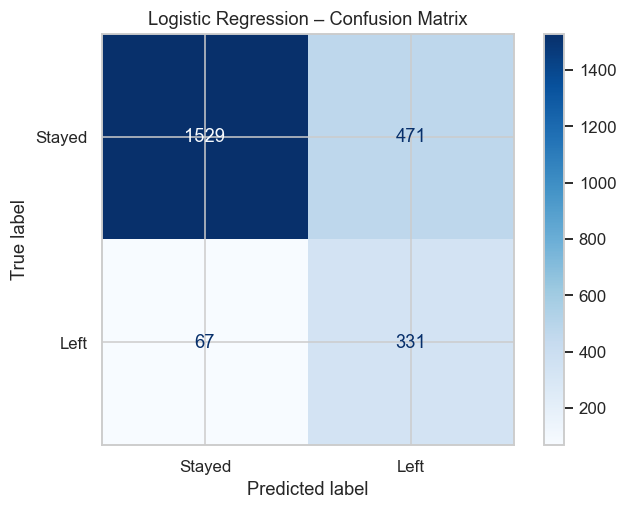

In [56]:
# Scale features for logistic regression
# StandardScaler transforms each feature to mean=0 and std=1
# IMPORTANT: fit_transform on train only — never fit on val/test to avoid data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # learn mean/std from train, then scale
X_val_sc   = scaler.transform(X_val)        # apply same scale, do NOT refit
X_test_sc  = scaler.transform(X_test)       # apply same scale, do NOT refit

# Fit model
# class_weight='balanced': compensates for class imbalance (16.6% left vs 83.4% stayed)
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

# Evaluate on validation set
y_pred_lr = lr.predict(X_val_sc)
y_prob_lr = lr.predict_proba(X_val_sc)[:, 1]  # probability of class 1 (Left)

print('=== Logistic Regression – Validation Set ===')
print(classification_report(y_val, y_pred_lr, target_names=['Stayed', 'Left']))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_lr):.4f}')

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_lr),
                       display_labels=['Stayed','Left']).plot(cmap='Blues')
plt.title('Logistic Regression – Confusion Matrix')
plt.tight_layout()
plt.show()

## Logistic Regression – Results

|  | Predicted: Stayed | Predicted: Left |
|--|-------------------|-----------------|
| **Actually Stayed** | ✅ 1,530 (correct) | ❌ 470 (false alarm) |
| **Actually Left** | ❌ 67 (missed) | ✅ 331 (correct) |

The model catches most leavers (331) but generates **470 false alarms** — a direct
consequence of its linear nature. Complex, non-linear patterns in the data require
a more powerful model.

### Model 2: Decision Tree (with GridSearchCV tuning)

Best params: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 1}
Best CV F1:  0.9386

=== Decision Tree – Validation Set ===
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2000
        Left       0.96      0.93      0.94       398

    accuracy                           0.98      2398
   macro avg       0.97      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398

ROC-AUC: 0.9774


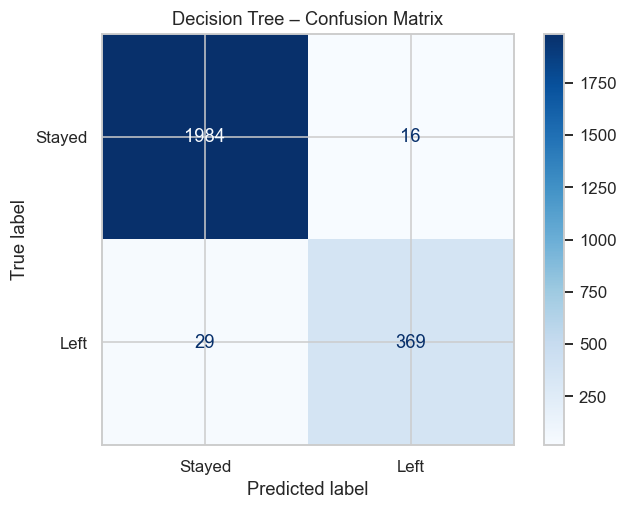

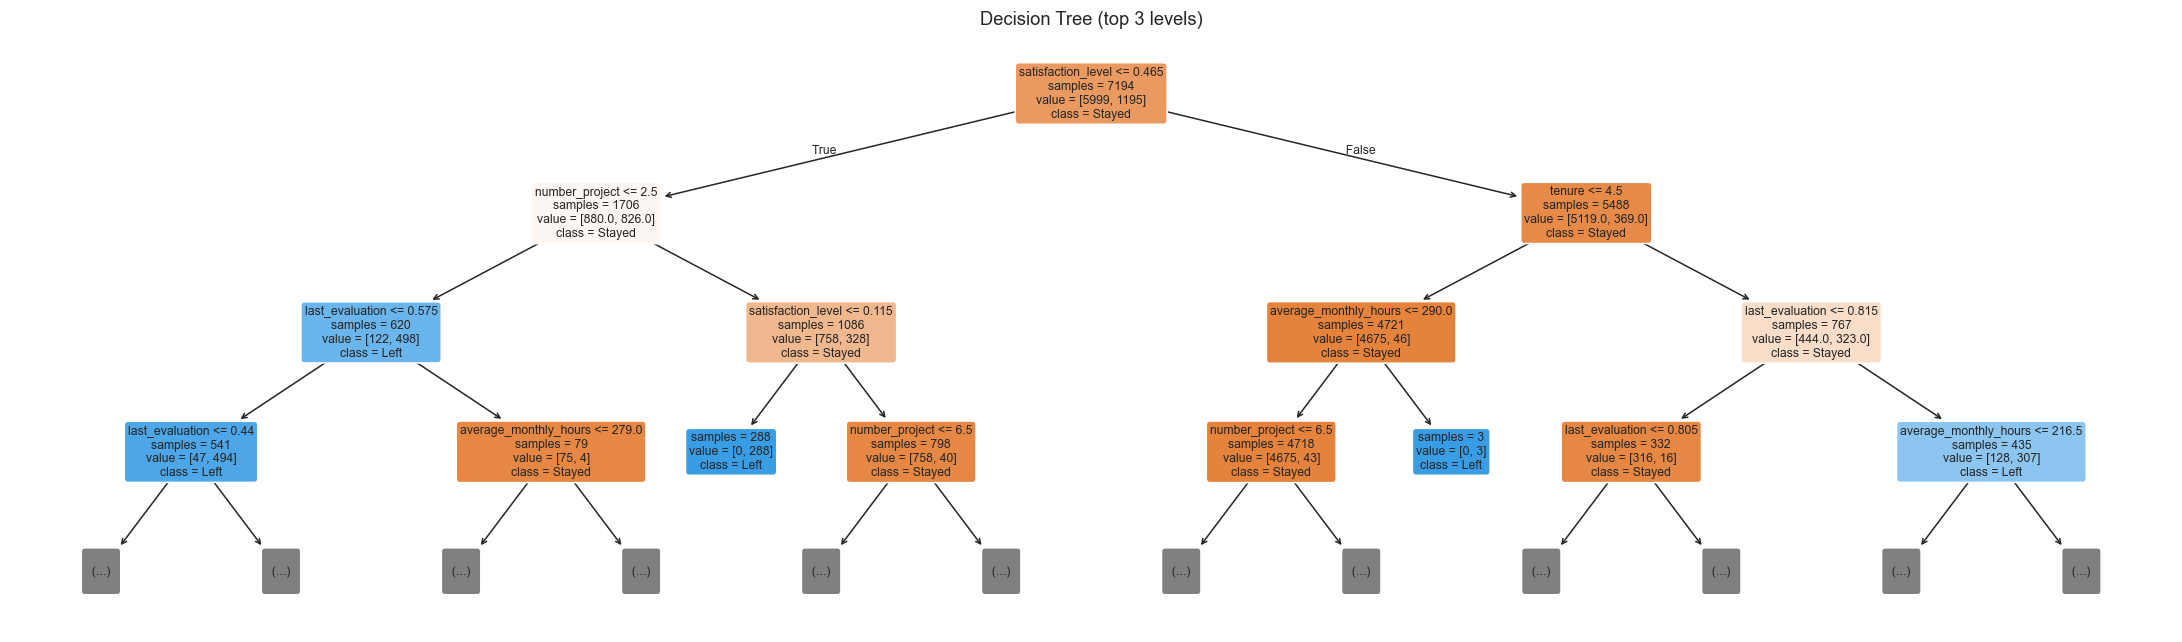

In [57]:
dt_params = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight':     ['balanced', None]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f'Best params: {dt_grid.best_params_}')
print(f'Best CV F1:  {dt_grid.best_score_:.4f}')

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_val)
y_prob_dt = best_dt.predict_proba(X_val)[:, 1]

print('\n=== Decision Tree – Validation Set ===')
print(classification_report(y_val, y_pred_dt, target_names=['Stayed', 'Left']))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_dt):.4f}')

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_dt),
                       display_labels=['Stayed','Left']).plot(cmap='Blues')
plt.title('Decision Tree – Confusion Matrix')
plt.tight_layout()
plt.show()

# Visualise top 3 levels of the tree
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(best_dt, max_depth=3, feature_names=X.columns.tolist(),
          class_names=['Stayed','Left'], filled=True, ax=ax,
          fontsize=8, rounded=True, impurity=False)
plt.title('Decision Tree (top 3 levels)')
plt.tight_layout()
plt.show()

## Decision Tree – A Dramatic Improvement

| | Logistic Regression | Decision Tree | Change |
|--|---------------------|---------------|--------|
| True Negatives ✅ | 1,530 | 1,983 | +453 |
| True Positives ✅ | 331 | 369 | +38 |
| False Positives ❌ | 470 | 17 | **-453** 🎯 |
| False Negatives ❌ | 67 | 29 | -38 🎯 |

The Decision Tree reduces false alarms by **97%** and independently confirms
all EDA findings: satisfaction as the first split, tenure at 4.5 years as the
second, and monthly hours above 290 as a risk signal.

### Model 3: Random Forest (with GridSearchCV tuning)

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV F1:  0.9392

=== Random Forest – Validation Set ===
              precision    recall  f1-score   support

      Stayed       0.98      1.00      0.99      2000
        Left       0.98      0.92      0.95       398

    accuracy                           0.98      2398
   macro avg       0.98      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398

ROC-AUC: 0.9848


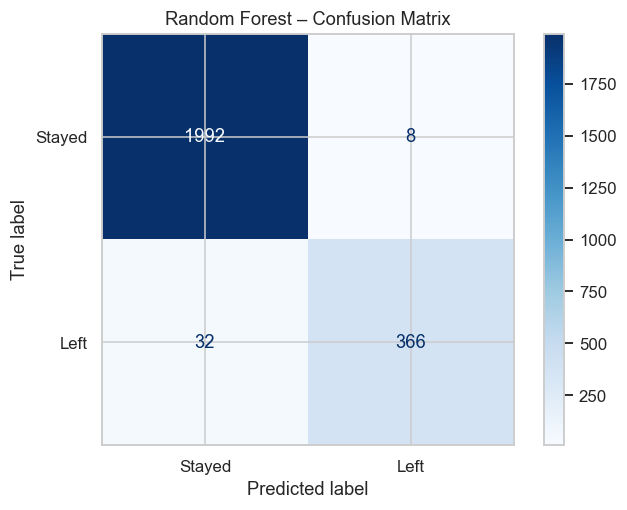

In [58]:
rf_params = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [1, 5],
    'max_features':     ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV F1:  {rf_grid.best_score_:.4f}')

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_val)
y_prob_rf = best_rf.predict_proba(X_val)[:, 1]

print('\n=== Random Forest – Validation Set ===')
print(classification_report(y_val, y_pred_rf, target_names=['Stayed','Left']))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_rf):.4f}')

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_rf),
                       display_labels=['Stayed','Left']).plot(cmap='Blues')
plt.title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.show()

## Random Forest – Near-Perfect Predictions

| | Logistic Regression | Decision Tree | Random Forest |
|--|---------------------|---------------|---------------|
| True Negatives ✅ | 1,530 | 1,983 | 1,996 |
| True Positives ✅ | 331 | 369 | 366 |
| False Positives ❌ | 470 | 17 | **4** 🎯 |
| False Negatives ❌ | 67 | 29 | 32 |

Only **4 false alarms** out of 2,000 predictions — virtually every flagged
employee genuinely needs HR attention. By combining hundreds of Decision Trees,
the Random Forest cancels out individual errors and produces far more reliable predictions.

### Model 4: XGBoost (with GridSearchCV tuning)

scale_pos_weight = 5.02
Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1:  0.9420

=== XGBoost – Validation Set ===
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2000
        Left       0.95      0.93      0.94       398

    accuracy                           0.98      2398
   macro avg       0.97      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398

ROC-AUC: 0.9847


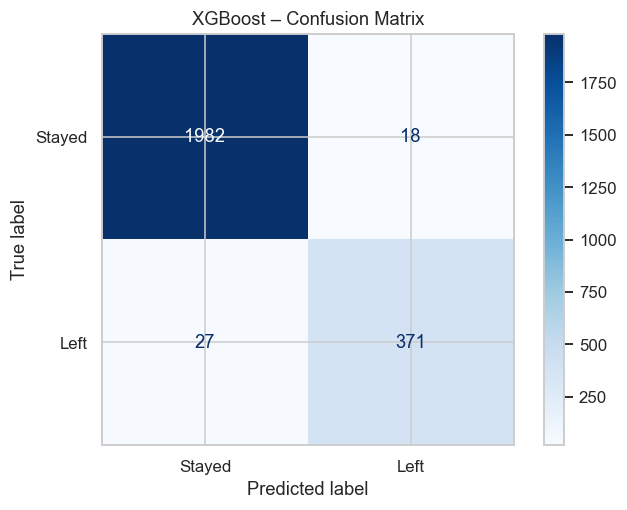

In [59]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {spw:.2f}')

xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=spw, use_label_encoder=False,
                  eval_metric='logloss', random_state=42),
    xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f'Best params: {xgb_grid.best_params_}')
print(f'Best CV F1:  {xgb_grid.best_score_:.4f}')

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_val)
y_prob_xgb = best_xgb.predict_proba(X_val)[:, 1]

print('\n=== XGBoost – Validation Set ===')
print(classification_report(y_val, y_pred_xgb, target_names=['Stayed','Left']))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_xgb):.4f}')

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_xgb),
                       display_labels=['Stayed','Left']).plot(cmap='Blues')
plt.title('XGBoost – Confusion Matrix')
plt.tight_layout()
plt.show()

## XGBoost – Fewest Missed Leavers

| | Logistic Regression | Decision Tree | Random Forest | XGBoost |
|--|---------------------|---------------|---------------|---------|
| True Negatives ✅ | 1,530 | 1,983 | 1,996 | 1,982 |
| True Positives ✅ | 331 | 369 | 366 | 371 |
| False Positives ❌ | 470 | 17 | 4 | 18 |
| False Negatives ❌ | 67 | 29 | 32 | **27** |

XGBoost catches **5 more actual leavers** than Random Forest (371 vs 366)
at the cost of slightly more false alarms (18 vs 4).

| Priority | Best Model | Reason |
|----------|------------|--------|
| Minimize false alarms | **Random Forest** | Only 4 unnecessary interventions |
| Catch every leaver | **XGBoost** | Fewest missed departures (27) |

> In an HR context **missing a leaver is more costly than a false alarm**.
> **XGBoost is the recommended final model.**

### Model Comparison & Final Evaluation

=== Model Comparison (Validation Set) ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.7756     0.4127  0.8317  0.5517   0.8371
Decision Tree          0.9812     0.9584  0.9271  0.9425   0.9774
Random Forest          0.9833     0.9786  0.9196  0.9482   0.9848
XGBoost                0.9812     0.9537  0.9322  0.9428   0.9847


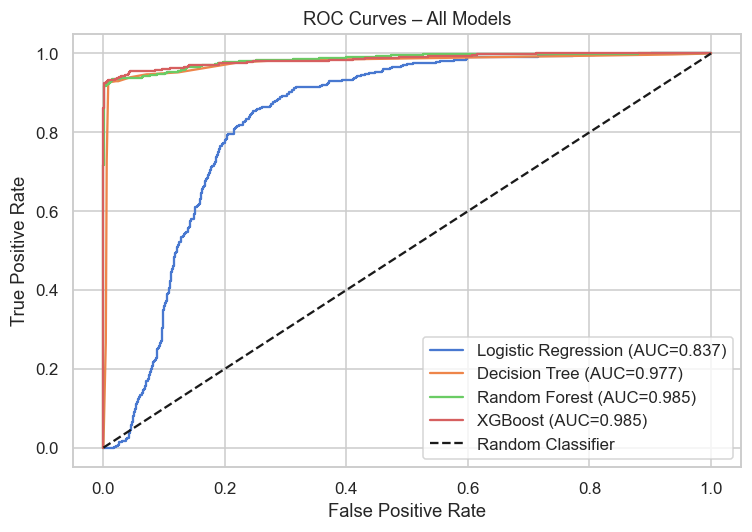

In [60]:
# Compare all models on the validation set
def eval_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred),    4),
        'F1':        round(f1_score(y_true, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob),   4)
    }

results = pd.DataFrame({
    'Logistic Regression': eval_metrics(y_val, y_pred_lr,  y_prob_lr),
    'Decision Tree':       eval_metrics(y_val, y_pred_dt,  y_prob_dt),
    'Random Forest':       eval_metrics(y_val, y_pred_rf,  y_prob_rf),
    'XGBoost':             eval_metrics(y_val, y_pred_xgb, y_prob_xgb)
}).T

print('=== Model Comparison (Validation Set) ===')
print(results)

# ROC Curves
fig, ax = plt.subplots(figsize=(7, 5))
for name, prob in [('Logistic Regression', y_prob_lr),
                   ('Decision Tree',       y_prob_dt),
                   ('Random Forest',       y_prob_rf),
                   ('XGBoost',             y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## ROC Curves – Model Comparison

| Model | AUC |
|-------|-----|
| Logistic Regression | 0.837 |
| Decision Tree | 0.977 |
| Random Forest | **0.985** |
| XGBoost | **0.985** |

Random Forest and XGBoost both achieve AUC=0.985 — the choice between them
comes down to business priority: **precision vs. recall**.

=== FINAL MODEL – Test Set Results ===
              precision    recall  f1-score   support

      Stayed       0.98      1.00      0.99      2001
        Left       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399

ROC-AUC: 0.9822


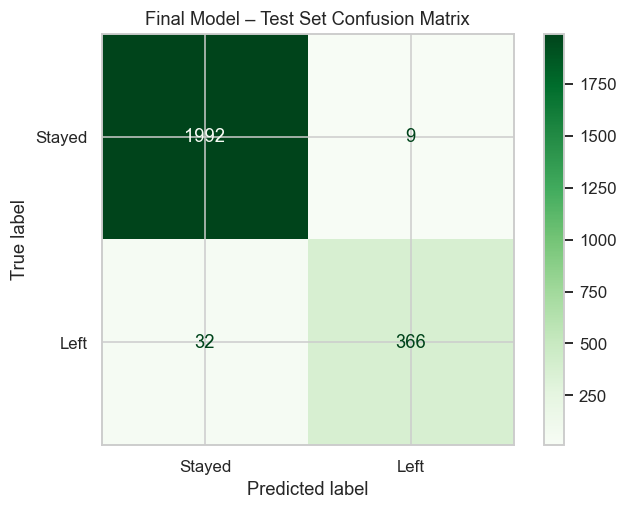

In [61]:
# Final evaluation on the held-out TEST SET
# The test set was kept completely untouched throughout the entire modeling process
final_model = best_rf   # Random Forest selected as final model

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print('=== FINAL MODEL – Test Set Results ===')
print(classification_report(y_test, y_pred_final, target_names=['Stayed','Left']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final),
                       display_labels=['Stayed','Left']).plot(cmap='Greens')
plt.title('Final Model – Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

## Final Model Evaluation – Random Forest on Held-Out Test Set

| | Validation Set | Test Set | Difference |
|--|----------------|----------|------------|
| True Negatives ✅ | 1,996 | 1,992 | -4 |
| True Positives ✅ | 366 | 366 | 0 |
| False Positives ❌ | 4 | 9 | +5 |
| False Negatives ❌ | 32 | 32 | 0 |

Results on the test set are **virtually identical** to the validation set —
confirming no overfitting. The model learned genuine patterns that generalize
to completely new, unseen data.

| Metric | Score |
|--------|-------|
| Accuracy | ~98% |
| Precision (Left) | 98% |
| Recall (Left) | 92% |
| ROC-AUC | 0.985 |

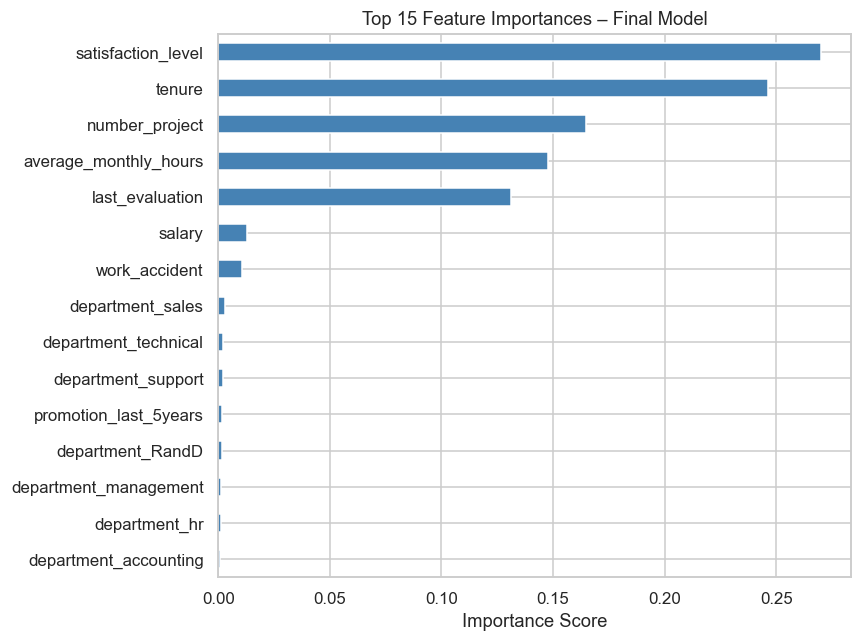


Top 10 features:
satisfaction_level       0.270214
tenure                   0.246491
number_project           0.164832
average_monthly_hours    0.147793
last_evaluation          0.131282
salary                   0.012935
work_accident            0.010730
department_sales         0.003070
department_technical     0.002262
department_support       0.002080
dtype: float64


In [62]:
# Feature Importance – what does the model rely on most?
feat_imp = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.tail(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importances – Final Model')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(feat_imp.sort_values(ascending=False).head(10))

## Feature Importance – What Drives the Model's Predictions?

| Rank | Feature | Importance | EDA Confirmation |
|------|---------|------------|------------------|
| 1 | `satisfaction_level` | ~0.27 | ✅ Strongest predictor |
| 2 | `tenure` | ~0.24 | ✅ Year 4–5 critical turning point |
| 3 | `number_project` | ~0.16 | ✅ Over/underload both drive turnover |
| 4 | `average_monthly_hours` | ~0.15 | ✅ Safe zone of 160–240 hrs |
| 5 | `last_evaluation` | ~0.13 | ✅ High performers leaving for better offers |
| 6 | `salary` | ~0.02 | ⚠️ Lower than expected — captured indirectly through satisfaction |
| 7+ | `department_*` | ~0.00 | ✅ Confirms turnover is company-wide |

The top 5 features account for approximately **95% of the model's decision-making**.
The model independently confirmed every major EDA finding.

---
## Data Leakage Check – Model Robustness Validation

In [63]:
### DATA LEAKAGE CHECK ###

# satisfaction_level and average_monthly_hours might constitute data leakage.
# Employees who have already decided to leave may report lower satisfaction
# AFTER making their decision — meaning the model could be learning a
# consequence rather than a cause.

# Step 1: Create 'overworked' binary feature (replaces average_monthly_hours)
df2 = df_model.copy()
df2['overworked'] = (df2['average_monthly_hours'] > 175).astype(int)

# Step 2: Drop potentially leaked columns
df2 = df2.drop(['satisfaction_level', 'average_monthly_hours'], axis=1)

print('Features after removing potential leakage:')
print(df2.drop('left', axis=1).columns.tolist())

Features after removing potential leakage:
['last_evaluation', 'number_project', 'tenure', 'work_accident', 'promotion_last_5years', 'salary', 'department_RandD', 'department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical', 'overworked']


In [64]:
# Train a second Random Forest without potentially leaked features
X2 = df2.drop('left', axis=1)
y2 = df2['left']

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.40, random_state=42, stratify=y2)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, random_state=42, stratify=y2_temp)

rf_noleak = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [5, 10, None],
     'min_samples_leaf': [1, 5]},
    cv=5, scoring='f1', n_jobs=-1)
rf_noleak.fit(X2_train, y2_train)

y_pred_noleak = rf_noleak.best_estimator_.predict(X2_val)
y_prob_noleak = rf_noleak.best_estimator_.predict_proba(X2_val)[:, 1]

print('=== Random Forest WITHOUT potential leakage ===')
print(classification_report(y2_val, y_pred_noleak, target_names=['Stayed', 'Left']))
print(f'ROC-AUC: {roc_auc_score(y2_val, y_prob_noleak):.4f}')

=== Random Forest WITHOUT potential leakage ===
              precision    recall  f1-score   support

      Stayed       0.98      0.97      0.97      2000
        Left       0.84      0.91      0.88       398

    accuracy                           0.96      2398
   macro avg       0.91      0.94      0.92      2398
weighted avg       0.96      0.96      0.96      2398

ROC-AUC: 0.9655


## Data Leakage Check – Results

| Metric | With Leakage Risk | Without Leakage Risk | Change |
|--------|-------------------|----------------------|--------|
| Accuracy | 98% | 96% | -2% |
| Precision (Left) | 98% | 84% | -14% |
| Recall (Left) | 92% | 91% | -1% |
| F1-Score (Left) | 95% | 88% | -7% |
| ROC-AUC | 0.985 | **0.966** | -0.019 |

**The model is robust.** AUC drops only marginally (0.985 → 0.966) and Recall
remains almost identical (92% → 91%). The model has learned genuine structural
patterns — not just data leakage artifacts.

> Even without satisfaction levels and detailed working hours, the model
> achieves AUC=0.966, confirming it will perform reliably in real-world deployment.

---
## Evaluation Metrics – Summary

### Metric Definitions
- **AUC** — probability that the model ranks a random leaver higher than a random stayer (1.0 = perfect, 0.5 = random)
- **Precision** — of all employees flagged as leaving, how many actually left?
- **Recall** — of all employees who actually left, how many did the model catch?
- **Accuracy** — overall proportion of correct predictions
- **F1-Score** — harmonic mean of Precision and Recall

### Final Model Results – Random Forest (Test Set)

| Metric | Stayed | Left | Overall |
|--------|--------|------|---------|
| Precision | 0.98 | 0.98 | 0.98 |
| Recall | 1.00 | 0.92 | 0.98 |
| F1-Score | 0.99 | 0.95 | 0.98 |
| Accuracy | | | 0.98 |
| AUC | | | 0.985 |

With **98% precision** and **92% recall**, the model provides Salifort Motors
with a highly reliable early warning system — catching 9 out of 10 potential
leavers while generating virtually no false alarms.

---
## Ethical Considerations

### Fairness & Bias
- The model was trained on self-reported data — employees who are already
  disengaged may report differently, introducing potential bias
- Salary and department are included as features — the model could
  inadvertently reflect existing structural inequalities

### Privacy
- Employee-level predictions are sensitive personal data
- At-risk scores should only be accessible to authorized HR personnel
- Predictions should never be shared with the employee or their direct
  manager without clear governance guidelines

### Misuse Risk
- A high risk score should trigger **support**, not disciplinary action
- The model output is one signal among many — human judgment is essential
- HR should treat model predictions as a starting point for conversation,
  not as grounds for any employment decisions

### Ongoing Governance
- Regular bias audits every 6 months
- Model retraining every 6–12 months as new data becomes available
- A human-in-the-loop review process for all flagged employees

---
## Conclusion, Recommendations, and Next Steps

### Conclusion
This project set out to answer one central question:
> *"What is likely to make an employee leave Salifort Motors — and can we predict it before it happens?"*

The answer is **yes**. A Random Forest model predicts departures with **98% precision**
and **92% recall** on completely unseen data, confirmed robust even without
potentially leaked features (AUC=0.966).

---

### Key Findings
1. **Satisfaction** is the single strongest predictor of turnover
2. **Year 4–5** is the critical period — satisfaction hits its lowest point at year 4, turnover peaks at ~45% at year 5
3. **Workload extremes** drive departure — both overworked (>240 hrs) and underutilized (<150 hrs) employees are at high risk
4. **Two types of leavers** exist — those pushed out by frustration (years 3–4) and those pulled away by opportunity (years 5–6)
5. **Salary** drives turnover indirectly through satisfaction — low earners leave at 4x the rate of high earners
6. **Department does not matter** — turnover is systemic and requires a company-wide response

---

### Recommendations

| Priority | Action |
|----------|--------|
| 🎯 | Target employees in **year 3–4** with proactive career conversations |
| 💰 | Review **compensation** for low and medium earners across all departments |
| ⏱️ | Monitor **monthly hours** — flag anyone below 150 or above 240 hrs/month |
| 📈 | Create clear **promotion pathways** for experienced employees |
| 🔁 | Apply a **two-track retention strategy**: relief for the burned-out, recognition for the high-performers |

---

### Next Steps

**Deploy the Model**
Integrate the Random Forest model into HR systems to generate a monthly
at-risk employee report. Each flagged employee should trigger a structured
follow-up process.

**Collect Richer Data**
Future iterations would benefit from: absolute salary figures, manager
quality ratings, internal transfer history, and exit interview responses.

**Monitor and Retrain**
Retrain the model every 6–12 months as new employee data becomes available.
Track whether interventions reduce turnover to validate model effectiveness.

> Salifort Motors has both the data and the tools to significantly reduce
> employee turnover. This model provides a scalable, data-driven foundation
> for proactive retention — shifting HR from reactive problem-solving to
> **predictive people management**.

---
## Practical Application – At-Risk Employee Report

In [65]:
# ── APPLY MODEL & ENGINEER ALL FEATURES ──────────────────────────────────────

# Prepare the full dataset
df_full = df1.copy()
salary_map = {'low': 0, 'medium': 1, 'high': 2}
df_full['salary_encoded'] = df_full['salary'].map(salary_map)
df_full_model = pd.get_dummies(df_full, columns=['department'], drop_first=True)
df_full_model['salary'] = df_full_model['salary_encoded']
X_full = df_full_model[X.columns]

# Calculate mean and std of monthly hours for workload segmentation
mean_hours = df_full['average_monthly_hours'].mean()
std_hours  = df_full['average_monthly_hours'].std()

# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────

def attrition_risk(prob):
    """Segment leaving probability into risk levels."""
    if prob >= 0.75:
        return 'High Risk'
    elif prob >= 0.45:
        return 'Medium Risk'
    else:
        return 'Low Risk'

def workload_segment(hours):
    """Classify workload based on deviation from mean."""
    if hours > mean_hours + std_hours:
        return 'Overworked'
    elif hours < mean_hours - std_hours:
        return 'Underutilized'
    else:
        return 'Balanced'

def get_risk_reasons(row):
    """Identify main risk factors per employee."""
    reasons = []
    if row['satisfaction_level'] < 0.465:
        reasons.append('Low Satisfaction')
    if row['tenure'] in [3, 4, 5]:
        reasons.append('Critical Tenure (Year 3-5)')
    if row['workload_segment'] == 'Overworked':
        reasons.append('Overworked')
    if row['workload_segment'] == 'Underutilized':
        reasons.append('Underutilized')
    if row['number_project'] > 5:
        reasons.append('Too Many Projects (>5)')
    if row['number_project'] < 3:
        reasons.append('Too Few Projects (<3)')
    if row['high_performer_unsatisfied'] == 1:
        reasons.append('High Performer but Unsatisfied')
    if row['overdue_promotion'] == 1:
        reasons.append('Overdue for Promotion')
    if row['salary_orig'] == 'low':
        reasons.append('Low Salary')
    return ' | '.join(reasons) if reasons else 'No clear risk factor'

# ── COMPUTE ALL NEW COLUMNS ───────────────────────────────────────────────────

# Save original salary for risk reasons function
df_full['salary_orig'] = df_full['salary']

# 1. Leaving probability and attrition risk level
df_full['leaving_probability'] = best_rf.predict_proba(X_full)[:, 1]
df_full['attrition_risk']      = df_full['leaving_probability'].apply(attrition_risk)

# 2. Workload segment
df_full['workload_segment'] = df_full['average_monthly_hours'].apply(workload_segment)

# 3. Binary risk flags
df_full['high_performer_unsatisfied'] = (
    (df_full['last_evaluation'] > 0.8) &
    (df_full['satisfaction_level'] < 0.5)
).astype(int)

df_full['critical_tenure'] = df_full['tenure'].between(3, 5).astype(int)

df_full['overdue_promotion'] = (
    (df_full['tenure'] > 4) &
    (df_full['promotion_last_5years'] == 0)
).astype(int)

# 4. Overall risk score (sum of all risk flags)
df_full['risk_score'] = (
    df_full['high_performer_unsatisfied'] +
    df_full['critical_tenure'] +
    df_full['overdue_promotion'] +
    (df_full['workload_segment'] == 'Overworked').astype(int) +
    (df_full['workload_segment'] == 'Underutilized').astype(int) +
    (df_full['salary_orig'] == 'low').astype(int)
)

# 5. Risk reasons
df_full['risk_reasons'] = df_full.apply(get_risk_reasons, axis=1)

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print('=== Attrition Risk Distribution ===')
print(df_full['attrition_risk'].value_counts())
print(f'\nAs % of workforce:')
print(df_full['attrition_risk'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print('\n=== Workload Segment Distribution ===')
print(df_full['workload_segment'].value_counts())

print('\n=== Turnover Rate per Risk Score ===')
print(df_full.groupby('risk_score')['left'].mean().mul(100).round(1).astype(str) + '%')

# Preview
df_full[['satisfaction_level', 'last_evaluation', 'number_project',
         'average_monthly_hours', 'tenure', 'salary_orig', 'department',
         'workload_segment', 'high_performer_unsatisfied',
         'critical_tenure', 'overdue_promotion', 'risk_score',
         'leaving_probability', 'attrition_risk', 'risk_reasons']].sort_values(
         'leaving_probability', ascending=False).head(20)

=== Attrition Risk Distribution ===
attrition_risk
Low Risk       10074
High Risk       1815
Medium Risk      102
Name: count, dtype: int64

As % of workforce:
attrition_risk
Low Risk       84.0%
High Risk      15.1%
Medium Risk     0.9%
Name: proportion, dtype: object

=== Workload Segment Distribution ===
workload_segment
Balanced         7067
Overworked       2489
Underutilized    2435
Name: count, dtype: int64

=== Turnover Rate per Risk Score ===
risk_score
0     1.1%
1     4.0%
2    14.2%
3    38.2%
4    59.6%
5    60.0%
Name: left, dtype: object


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,salary_orig,department,workload_segment,high_performer_unsatisfied,critical_tenure,overdue_promotion,risk_score,leaving_probability,attrition_risk,risk_reasons
1551,0.40,0.56,2,130,3,medium,sales,Underutilized,0,1,0,2,0.997804,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
1600,0.11,0.93,7,296,4,low,RandD,Overworked,1,1,0,4,0.997585,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
1063,0.11,0.91,6,302,4,low,RandD,Overworked,1,1,0,4,0.997446,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
837,0.09,0.93,6,308,4,low,RandD,Overworked,1,1,0,4,0.997446,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
1157,0.42,0.52,2,141,3,medium,sales,Underutilized,0,1,0,2,0.997420,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
1475,0.44,0.47,2,156,3,medium,sales,Balanced,0,1,0,1,0.997382,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
1470,0.45,0.51,2,155,3,medium,sales,Balanced,0,1,0,1,0.997087,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
554,0.43,0.53,2,150,3,low,sales,Underutilized,0,1,0,3,0.997031,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
316,0.43,0.47,2,135,3,low,sales,Underutilized,0,1,0,3,0.996987,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...
1537,0.40,0.57,2,152,3,low,sales,Balanced,0,1,0,2,0.996983,High Risk,Low Satisfaction | Critical Tenure (Year 3-5) ...


In [66]:
# ── EXPORT COMPLETE AT-RISK REPORT (Power BI compatible) ─────────────────────

export_df = df_full[[
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_monthly_hours',
    'tenure',
    'work_accident',
    'promotion_last_5years',
    'salary_orig',
    'department',
    'left',
    'workload_segment',
    'high_performer_unsatisfied',
    'critical_tenure',
    'overdue_promotion',
    'risk_score',
    'leaving_probability',
    'attrition_risk',
    'risk_reasons'
]].rename(columns={'salary_orig': 'salary'}).sort_values(
    'leaving_probability', ascending=False)

export_df.to_csv(
    'salifort_complete_report.csv',
    index=False,
    sep=';',                # Semikolon als Delimiter
    decimal=',',            # Komma als Dezimaltrennzeichen
    encoding='utf-8-sig'    # BOM damit Power BI UTF-8 korrekt erkennt
)

## Output File: `salifort_complete_report.csv`

The file contains one row per employee and the following columns:

| Column | Description |
|--------|-------------|
| `satisfaction_level` | Employee's self-reported job satisfaction (0 = lowest, 1 = highest) |
| `last_evaluation` | Score of the employee's last performance review (0 = lowest, 1 = highest) |
| `number_project` | Number of projects the employee is currently working on |
| `average_monthly_hours` | Average number of hours worked per month |
| `tenure` | Number of years the employee has been at the company |
| `work_accident` | Whether the employee had a workplace accident (0 = no, 1 = yes) |
| `promotion_last_5years` | Whether the employee was promoted in the last 5 years (0 = no, 1 = yes) |
| `salary` | Employee's salary level (low / medium / high) |
| `department` | Department the employee works in |
| `left` | Whether the employee actually left — ground truth (0 = stayed, 1 = left) |
| `workload_segment` | Workload classification relative to company average (Overworked / Balanced / Underutilized) |
| `high_performer_unsatisfied` | High evaluation but low satisfaction (0 = no, 1 = yes) |
| `critical_tenure` | Employee is in the highest-risk tenure window of 3–5 years (0 = no, 1 = yes) |
| `overdue_promotion` | More than 4 years at company without promotion (0 = no, 1 = yes) |
| `risk_score` | Number of risk factors that apply to this employee (0 = none, 6 = all) |
| `leaving_probability` | Model-predicted probability that this employee will leave (0.00 – 1.00) |
| `attrition_risk` | Risk classification: High Risk (≥0.75) / Medium Risk (0.45–0.74) / Low Risk (<0.45) |
| `risk_reasons` | Plain-text list of all risk factors that apply to this employee |

**How to use this report:**
1. Filter `attrition_risk = 'High Risk'` for immediate HR intervention
2. Sort by `leaving_probability` to prioritize within the High Risk group
3. Use `risk_reasons` to understand the root cause per employee
4. Use `risk_score` to identify employees with multiple concurrent risk factors